# Reproducible local TimeBase+Informer run

This notebook now has a script-backed path that mirrors the TimeBase+PMFormer folder. Run the cell below to regenerate `results/` with training/validation loss curves, metrics, checkpoints, and prediction samples.


In [ ]:
!python -u train_timebase_informer.py --epochs 5 --horizons 1 8 16 24 --results-dir results


In [ ]:
from google.colab import files
uploaded = files.upload()

file_path = list(uploaded.keys())[0]
print("Uploaded file:", file_path)

Saving Load House 1.csv to Load House 1.csv
Uploaded file: Load House 1.csv


In [ ]:
import math
import copy
import gc
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

SEQ_LEN = 720
BATCH_SIZE = 64

HORIZONS = [1, 8, 16, 24]
EPOCHS = 10

TB_P = 24
TB_R = 6
TB_LAMBDA_ORTH = 0.04

TIMEBASE_LR = 0.01
RESIDUAL_LR = 0.001

RECENT_LEN = 48
D_MODEL = 32
N_HEADS = 4
D_FF = 64
DROPOUT = 0.1

Device: cuda


Original shape: (111068, 6)


,Date,Hour,Day of the Week,Season,Daytime,Consumption (kW)
0,2021-03-01,00:00:00,0,1,0,0.096
1,2021-03-01,00:15:00,0,1,0,0.196
2,2021-03-01,00:30:00,0,1,0,0.128
3,2021-03-01,00:45:00,0,1,0,0.156
4,2021-03-01,01:00:00,0,1,0,0.096



Missing values before cleaning:
datetime       0
consumption    0
dtype: int64

Cleaned 15-min shape: (111073, 2)
datetime       0
consumption    0
dtype: int64

15-min gap check:
datetime
0 days 00:15:00    111072
Name: count, dtype: int64

Hourly shape: (27769, 2)


,datetime,consumption
0,2021-03-01 00:00:00,0.144
1,2021-03-01 01:00:00,0.075
2,2021-03-01 02:00:00,0.126
3,2021-03-01 03:00:00,0.063
4,2021-03-01 04:00:00,0.082



Hourly gap check:
datetime
0 days 01:00:00    27768
Name: count, dtype: int64


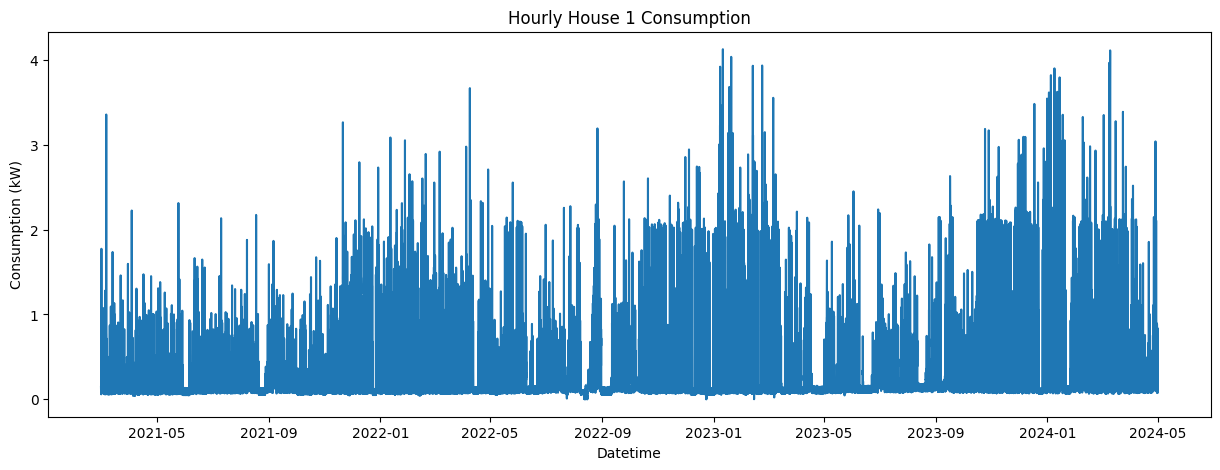

In [ ]:
df = pd.read_csv(file_path)

print("Original shape:", df.shape)
display(df.head())

df["datetime"] = pd.to_datetime(df["Date"] + " " + df["Hour"])
df = df.sort_values("datetime").reset_index(drop=True)

data = df[["datetime", "Consumption (kW)"]].copy()
data.rename(columns={"Consumption (kW)": "consumption"}, inplace=True)

print("\nMissing values before cleaning:")
print(data.isnull().sum())

data = data.groupby("datetime", as_index=False)["consumption"].mean()

full_time = pd.date_range(
    start=data["datetime"].min(),
    end=data["datetime"].max(),
    freq="15min"
)

data = data.set_index("datetime").reindex(full_time)
data.index.name = "datetime"

data["consumption"] = data["consumption"].interpolate(method="time")
data["consumption"] = data["consumption"].ffill().bfill()

data = data.reset_index()

print("\nCleaned 15-min shape:", data.shape)
print(data.isnull().sum())

print("\n15-min gap check:")
print(data["datetime"].diff().value_counts().head())

hourly_data = data.set_index("datetime").resample("1h").mean()
hourly_data = hourly_data.interpolate(method="time")
hourly_data = hourly_data.ffill().bfill()
hourly_data = hourly_data.reset_index()

print("\nHourly shape:", hourly_data.shape)
display(hourly_data.head())

print("\nHourly gap check:")
print(hourly_data["datetime"].diff().value_counts().head())

plt.figure(figsize=(15, 5))
plt.plot(hourly_data["datetime"], hourly_data["consumption"])
plt.title("Hourly House 1 Consumption")
plt.xlabel("Datetime")
plt.ylabel("Consumption (kW)")
plt.show()

In [ ]:
dfh = hourly_data[["datetime", "consumption"]].copy()
dfh = dfh.sort_values("datetime").reset_index(drop=True)

vals = dfh[["consumption"]].values.astype(np.float32)

n = len(vals)
tr_end = int(n * 0.7)
va_end = int(n * 0.8)

scaler = StandardScaler()
scaler.fit(vals[:tr_end])

vals_s = scaler.transform(vals).astype(np.float32)

train_arr = vals_s[:tr_end]
val_arr = vals_s[tr_end - SEQ_LEN : va_end]
test_arr = vals_s[va_end - SEQ_LEN :]

print("Total hourly points:", n)
print("Train:", train_arr.shape)
print("Val:", val_arr.shape)
print("Test:", test_arr.shape)

print("\nTrain date range:", dfh["datetime"].iloc[0], "to", dfh["datetime"].iloc[tr_end - 1])
print("Val date range:", dfh["datetime"].iloc[tr_end], "to", dfh["datetime"].iloc[va_end - 1])
print("Test date range:", dfh["datetime"].iloc[va_end], "to", dfh["datetime"].iloc[-1])

Total hourly points: 27769
Train: (19438, 1)
Val: (3497, 1)
Test: (6274, 1)

Train date range: 2021-03-01 00:00:00 to 2023-05-19 21:00:00
Val date range: 2023-05-19 22:00:00 to 2023-09-12 14:00:00
Test date range: 2023-09-12 15:00:00 to 2024-05-01 00:00:00


In [ ]:
class ForecastDataset(Dataset):
    def __init__(self, arr, seq_len, pred_len):
        self.arr = arr.astype(np.float32)
        self.seq_len = seq_len
        self.pred_len = pred_len

    def __len__(self):
        return len(self.arr) - self.seq_len - self.pred_len + 1

    def __getitem__(self, i):
        x = self.arr[i : i + self.seq_len]
        y = self.arr[i + self.seq_len : i + self.seq_len + self.pred_len]

        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(y, dtype=torch.float32)

        return x, y


def make_loaders(pred_len):
    tr_ds = ForecastDataset(train_arr, SEQ_LEN, pred_len)
    va_ds = ForecastDataset(val_arr, SEQ_LEN, pred_len)
    te_ds = ForecastDataset(test_arr, SEQ_LEN, pred_len)

    tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True)
    va_loader = DataLoader(va_ds, batch_size=BATCH_SIZE, shuffle=False)
    te_loader = DataLoader(te_ds, batch_size=BATCH_SIZE, shuffle=False)

    print(f"\n{pred_len}h forecast")
    print("Train samples:", len(tr_ds))
    print("Val samples:", len(va_ds))
    print("Test samples:", len(te_ds))

    return tr_loader, va_loader, te_loader

In [ ]:
class TimeBaseCore(nn.Module):
    def __init__(self, seq_len, pred_len, seg_len=24, basis_num=6):
        super().__init__()

        self.seq_len = seq_len
        self.pred_len = pred_len
        self.seg_len = seg_len
        self.basis_num = basis_num

        self.n_seg = math.ceil(seq_len / seg_len)
        self.n_pred_seg = math.ceil(pred_len / seg_len)

        self.basis_extract = nn.Linear(self.n_seg, basis_num)
        self.segment_forecast = nn.Linear(basis_num, self.n_pred_seg)

    def forward(self, x):
        b, t, c = x.shape

        need = self.n_seg * self.seg_len - t

        if need > 0:
            pad = x[:, -1:, :].repeat(1, need, 1)
            x = torch.cat([x, pad], dim=1)

        x = x.permute(0, 2, 1)
        x = x.reshape(b, c, self.n_seg, self.seg_len)

        x = x.permute(0, 1, 3, 2)

        basis = self.basis_extract(x)

        basis = basis.permute(0, 1, 3, 2)

        z = basis.permute(0, 1, 3, 2)

        out = self.segment_forecast(z)

        out = out.permute(0, 1, 3, 2)
        out = out.reshape(b, c, self.n_pred_seg * self.seg_len)

        out = out[:, :, :self.pred_len]
        out = out.permute(0, 2, 1)

        return out, basis


class BaseTimeBase(nn.Module):
    def __init__(self, seq_len, pred_len):
        super().__init__()

        self.timebase = TimeBaseCore(
            seq_len=seq_len,
            pred_len=pred_len,
            seg_len=TB_P,
            basis_num=TB_R
        )

    def forward(self, x):
        y, basis = self.timebase(x)
        return y, basis, None

In [ ]:
def orth_loss(basis):
    b, c, r, p = basis.shape

    z = basis.reshape(b * c, r, p)

    z = z / (torch.norm(z, dim=-1, keepdim=True) + 1e-8)

    g = torch.matmul(z, z.transpose(1, 2))

    diag = torch.diag_embed(torch.diagonal(g, dim1=1, dim2=2))

    off_diag = g - diag

    return torch.mean(off_diag ** 2)

In [ ]:
class LocalResidualEncoder(nn.Module):
    def __init__(
        self,
        pred_len,
        recent_len=48,
        d_model=32,
        n_heads=4,
        d_ff=64,
        dropout=0.1
    ):
        super().__init__()

        self.pred_len = pred_len
        self.recent_len = recent_len

        self.value_proj = nn.Linear(1, d_model)

        self.pos = nn.Parameter(torch.zeros(1, recent_len, d_model))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=1
        )

        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, pred_len)
        )

    def forward(self, x):
        recent = x[:, -self.recent_len:, :]

        z = self.value_proj(recent)

        z = z + self.pos

        z = self.encoder(z)

        z = z.mean(dim=1)

        residual = self.head(z)

        residual = residual.unsqueeze(-1)

        return residual

In [ ]:
class TimeBaseResidualEncoder(nn.Module):
    def __init__(self, seq_len, pred_len):
        super().__init__()

        self.timebase = TimeBaseCore(
            seq_len=seq_len,
            pred_len=pred_len,
            seg_len=TB_P,
            basis_num=TB_R
        )

        self.residual_encoder = LocalResidualEncoder(
            pred_len=pred_len,
            recent_len=RECENT_LEN,
            d_model=D_MODEL,
            n_heads=N_HEADS,
            d_ff=D_FF,
            dropout=DROPOUT
        )

        self.gate = nn.Parameter(torch.tensor(-2.0))

    def forward(self, x):
        base_pred, basis = self.timebase(x)

        residual = self.residual_encoder(x)

        gate_value = torch.sigmoid(self.gate)

        final_pred = base_pred + gate_value * residual

        return final_pred, basis, gate_value

In [ ]:
@torch.no_grad()
def evaluate_model(model, loader):
    model.eval()

    preds = []
    trues = []

    for x, y in loader:
        x = x.to(device)

        pred, basis, gate = model(x)

        preds.append(pred.cpu().numpy())
        trues.append(y.numpy())

    preds = np.concatenate(preds, axis=0)
    trues = np.concatenate(trues, axis=0)

    preds_real = scaler.inverse_transform(preds.reshape(-1, 1)).reshape(preds.shape)
    trues_real = scaler.inverse_transform(trues.reshape(-1, 1)).reshape(trues.shape)

    mae = mean_absolute_error(trues_real.reshape(-1), preds_real.reshape(-1))
    mse = mean_squared_error(trues_real.reshape(-1), preds_real.reshape(-1))
    rmse = np.sqrt(mse)

    return mae, mse, rmse, preds_real, trues_real

In [ ]:
def train_model(model_name, model, pred_len, lr):
    print("\n" + "=" * 60)
    print(f"Training {model_name} for {pred_len} hour forecast")
    print("=" * 60)

    tr_loader, va_loader, te_loader = make_loaders(pred_len)

    model = model.to(device)

    params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print("Trainable parameters:", params)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []

    for epoch in range(1, EPOCHS + 1):
        model.train()

        train_loss = 0.0

        for x, y in tr_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            pred, basis, gate = model(x)

            pred_loss = criterion(pred, y)

            o_loss = orth_loss(basis)

            loss = pred_loss + TB_LAMBDA_ORTH * o_loss

            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()

            train_loss += loss.item() * x.size(0)

        train_loss = train_loss / len(tr_loader.dataset)

        model.eval()

        val_loss = 0.0

        with torch.no_grad():
            for x, y in va_loader:
                x = x.to(device)
                y = y.to(device)

                pred, basis, gate = model(x)

                pred_loss = criterion(pred, y)

                o_loss = orth_loss(basis)

                loss = pred_loss + TB_LAMBDA_ORTH * o_loss

                val_loss += loss.item() * x.size(0)

        val_loss = val_loss / len(va_loader.dataset)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if gate is not None:
            g = gate.item()
            print(
                f"Epoch [{epoch}/{EPOCHS}] "
                f"Train Loss: {train_loss:.6f} | "
                f"Val Loss: {val_loss:.6f} | "
                f"Gate: {g:.4f}"
            )
        else:
            print(
                f"Epoch [{epoch}/{EPOCHS}] "
                f"Train Loss: {train_loss:.6f} | "
                f"Val Loss: {val_loss:.6f}"
            )

    mae, mse, rmse, preds_real, trues_real = evaluate_model(model, te_loader)

    print(f"\n{model_name} {pred_len} hour forecast")
    print("MAE:", mae)
    print("MSE:", mse)
    print("RMSE:", rmse)

    return {
        "Model": model_name,
        "Horizon": pred_len,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "Params": params,
        "Train Losses": train_losses,
        "Val Losses": val_losses,
        "Preds": preds_real,
        "Trues": trues_real
    }

In [ ]:
all_results = []

for h in HORIZONS:
    base_model = BaseTimeBase(
        seq_len=SEQ_LEN,
        pred_len=h
    )

    base_out = train_model(
        model_name="Base TimeBase",
        model=base_model,
        pred_len=h,
        lr=TIMEBASE_LR
    )

    all_results.append(base_out)

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    residual_model = TimeBaseResidualEncoder(
        seq_len=SEQ_LEN,
        pred_len=h
    )

    residual_out = train_model(
        model_name="TimeBase + Residual Encoder",
        model=residual_model,
        pred_len=h,
        lr=RESIDUAL_LR
    )

    all_results.append(residual_out)

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


Training Base TimeBase for 1 hour forecast

1h forecast
Train samples: 18718
Val samples: 2777
Test samples: 5554
Trainable parameters: 193
Epoch [1/10] Train Loss: 0.744126 | Val Loss: 0.300318
Epoch [2/10] Train Loss: 0.721922 | Val Loss: 0.294617
Epoch [3/10] Train Loss: 0.718924 | Val Loss: 0.302525
Epoch [4/10] Train Loss: 0.715975 | Val Loss: 0.297836
Epoch [5/10] Train Loss: 0.714683 | Val Loss: 0.288231
Epoch [6/10] Train Loss: 0.713879 | Val Loss: 0.292021
Epoch [7/10] Train Loss: 0.713237 | Val Loss: 0.295253
Epoch [8/10] Train Loss: 0.714278 | Val Loss: 0.299664
Epoch [9/10] Train Loss: 0.712224 | Val Loss: 0.296380
Epoch [10/10] Train Loss: 0.712339 | Val Loss: 0.303000

Base TimeBase 1 hour forecast
MAE: 0.38186073303222656
MSE: 0.3116205930709839
RMSE: 0.5582298747567922


/tmp/ipykernel_1190/2706688416.py:30: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(



Training TimeBase + Residual Encoder for 1 hour forecast

1h forecast
Train samples: 18718
Val samples: 2777
Test samples: 5554
Trainable parameters: 10435
Epoch [1/10] Train Loss: 0.747872 | Val Loss: 0.243822 | Gate: 0.1273
Epoch [2/10] Train Loss: 0.497400 | Val Loss: 0.226898 | Gate: 0.1418
Epoch [3/10] Train Loss: 0.465705 | Val Loss: 0.226356 | Gate: 0.1464
Epoch [4/10] Train Loss: 0.454977 | Val Loss: 0.228607 | Gate: 0.1499
Epoch [5/10] Train Loss: 0.452633 | Val Loss: 0.221217 | Gate: 0.1511
Epoch [6/10] Train Loss: 0.453167 | Val Loss: 0.223583 | Gate: 0.1522
Epoch [7/10] Train Loss: 0.448898 | Val Loss: 0.229040 | Gate: 0.1531
Epoch [8/10] Train Loss: 0.445498 | Val Loss: 0.223887 | Gate: 0.1531
Epoch [9/10] Train Loss: 0.436461 | Val Loss: 0.226359 | Gate: 0.1548
Epoch [10/10] Train Loss: 0.437215 | Val Loss: 0.223988 | Gate: 0.1553

TimeBase + Residual Encoder 1 hour forecast
MAE: 0.2811986207962036
MSE: 0.19426560401916504
RMSE: 0.4407557192132225

Training Base TimeBase

/tmp/ipykernel_1190/2706688416.py:30: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


Epoch [1/10] Train Loss: 0.731992 | Val Loss: 0.287941 | Gate: 0.1297
Epoch [2/10] Train Loss: 0.669437 | Val Loss: 0.279519 | Gate: 0.1364
Epoch [3/10] Train Loss: 0.654428 | Val Loss: 0.278812 | Gate: 0.1425
Epoch [4/10] Train Loss: 0.647789 | Val Loss: 0.276013 | Gate: 0.1488
Epoch [5/10] Train Loss: 0.642437 | Val Loss: 0.276734 | Gate: 0.1526
Epoch [6/10] Train Loss: 0.637543 | Val Loss: 0.277348 | Gate: 0.1570
Epoch [7/10] Train Loss: 0.635037 | Val Loss: 0.276947 | Gate: 0.1593
Epoch [8/10] Train Loss: 0.631626 | Val Loss: 0.276529 | Gate: 0.1617
Epoch [9/10] Train Loss: 0.630873 | Val Loss: 0.274873 | Gate: 0.1635
Epoch [10/10] Train Loss: 0.629186 | Val Loss: 0.277130 | Gate: 0.1647

TimeBase + Residual Encoder 8 hour forecast
MAE: 0.3603643476963043
MSE: 0.2838842570781708
RMSE: 0.5328078988511439

Training Base TimeBase for 16 hour forecast

16h forecast
Train samples: 18703
Val samples: 2762
Test samples: 5539
Trainable parameters: 193
Epoch [1/10] Train Loss: 0.722277 | Va

/tmp/ipykernel_1190/2706688416.py:30: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(



Training TimeBase + Residual Encoder for 16 hour forecast

16h forecast
Train samples: 18703
Val samples: 2762
Test samples: 5539
Trainable parameters: 10930
Epoch [1/10] Train Loss: 0.727096 | Val Loss: 0.290065 | Gate: 0.1293
Epoch [2/10] Train Loss: 0.685625 | Val Loss: 0.284045 | Gate: 0.1351
Epoch [3/10] Train Loss: 0.672520 | Val Loss: 0.284816 | Gate: 0.1398
Epoch [4/10] Train Loss: 0.667106 | Val Loss: 0.283122 | Gate: 0.1431
Epoch [5/10] Train Loss: 0.663244 | Val Loss: 0.282139 | Gate: 0.1458
Epoch [6/10] Train Loss: 0.659596 | Val Loss: 0.282317 | Gate: 0.1504
Epoch [7/10] Train Loss: 0.657273 | Val Loss: 0.281311 | Gate: 0.1530
Epoch [8/10] Train Loss: 0.655898 | Val Loss: 0.282988 | Gate: 0.1546
Epoch [9/10] Train Loss: 0.654813 | Val Loss: 0.280529 | Gate: 0.1565
Epoch [10/10] Train Loss: 0.652520 | Val Loss: 0.279143 | Gate: 0.1600

TimeBase + Residual Encoder 16 hour forecast
MAE: 0.36246824264526367
MSE: 0.2956874370574951
RMSE: 0.5437714934211751

Training Base TimeB

/tmp/ipykernel_1190/2706688416.py:30: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(



Training TimeBase + Residual Encoder for 24 hour forecast

24h forecast
Train samples: 18695
Val samples: 2754
Test samples: 5531
Trainable parameters: 11194
Epoch [1/10] Train Loss: 0.762079 | Val Loss: 0.284879 | Gate: 0.1297
Epoch [2/10] Train Loss: 0.684021 | Val Loss: 0.286821 | Gate: 0.1327
Epoch [3/10] Train Loss: 0.676268 | Val Loss: 0.284214 | Gate: 0.1365
Epoch [4/10] Train Loss: 0.674243 | Val Loss: 0.286810 | Gate: 0.1387
Epoch [5/10] Train Loss: 0.672188 | Val Loss: 0.282554 | Gate: 0.1410
Epoch [6/10] Train Loss: 0.671227 | Val Loss: 0.282831 | Gate: 0.1425
Epoch [7/10] Train Loss: 0.670226 | Val Loss: 0.280516 | Gate: 0.1441
Epoch [8/10] Train Loss: 0.669526 | Val Loss: 0.281440 | Gate: 0.1453
Epoch [9/10] Train Loss: 0.668241 | Val Loss: 0.280705 | Gate: 0.1465
Epoch [10/10] Train Loss: 0.667154 | Val Loss: 0.281866 | Gate: 0.1475

TimeBase + Residual Encoder 24 hour forecast
MAE: 0.3709859251976013
MSE: 0.3009795546531677
RMSE: 0.5486160357236814


In [ ]:
result_df = pd.DataFrame([
    {
        "Model": x["Model"],
        "Horizon": x["Horizon"],
        "MAE": x["MAE"],
        "MSE": x["MSE"],
        "RMSE": x["RMSE"],
        "Params": x["Params"]
    }
    for x in all_results
])

result_df = result_df.sort_values(["Horizon", "Model"]).reset_index(drop=True)

display(result_df)

,Model,Horizon,MAE,MSE,RMSE,Params
0,Base TimeBase,1,0.381861,0.311621,0.558230,193
1,TimeBase + Residual Encoder,1,0.281199,0.194266,0.440756,10435
2,Base TimeBase,8,0.377974,0.312667,0.559166,193
3,TimeBase + Residual Encoder,8,0.360364,0.283884,0.532808,10666
4,Base TimeBase,16,0.381222,0.318586,0.564434,193
5,TimeBase + Residual Encoder,16,0.362468,0.295687,0.543771,10930
6,Base TimeBase,24,0.375301,0.311593,0.558205,193
7,TimeBase + Residual Encoder,24,0.370986,0.300980,0.548616,11194


In [ ]:
base_df = result_df[result_df["Model"] == "Base TimeBase"].copy()

res_df = result_df[result_df["Model"] == "TimeBase + Residual Encoder"].copy()

compare_df = base_df.merge(
    res_df,
    on="Horizon",
    suffixes=("_Base", "_Residual")
)

compare_df["MAE_Improvement"] = compare_df["MAE_Base"] - compare_df["MAE_Residual"]

compare_df["MSE_Improvement"] = compare_df["MSE_Base"] - compare_df["MSE_Residual"]

compare_df["MAE_Improvement_%"] = (
    compare_df["MAE_Improvement"] / compare_df["MAE_Base"]
) * 100

compare_df["MSE_Improvement_%"] = (
    compare_df["MSE_Improvement"] / compare_df["MSE_Base"]
) * 100

display(compare_df)

,Model_Base,Horizon,MAE_Base,MSE_Base,RMSE_Base,Params_Base,Model_Residual,MAE_Residual,MSE_Residual,RMSE_Residual,Params_Residual,MAE_Improvement,MSE_Improvement,MAE_Improvement_%,MSE_Improvement_%
0,Base TimeBase,1,0.381861,0.311621,0.558230,193,TimeBase + Residual Encoder,0.281199,0.194266,0.440756,10435,0.100662,0.117355,26.360949,37.659574
1,Base TimeBase,8,0.377974,0.312667,0.559166,193,TimeBase + Residual Encoder,0.360364,0.283884,0.532808,10666,0.017609,0.028783,4.658892,9.205545
2,Base TimeBase,16,0.381222,0.318586,0.564434,193,TimeBase + Residual Encoder,0.362468,0.295687,0.543771,10930,0.018754,0.022898,4.919389,7.187472
3,Base TimeBase,24,0.375301,0.311593,0.558205,193,TimeBase + Residual Encoder,0.370986,0.300980,0.548616,11194,0.004315,0.010614,1.149851,3.406289


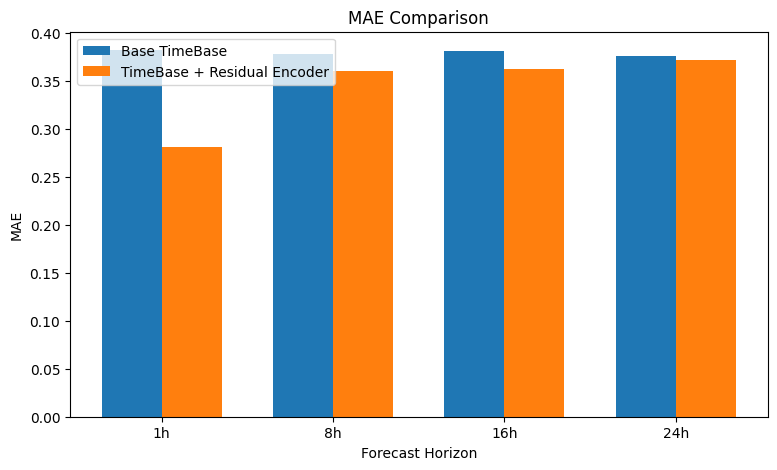

In [ ]:
mae_pivot = result_df.pivot(index="Horizon", columns="Model", values="MAE")

x = np.arange(len(HORIZONS))
w = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - w / 2,
    mae_pivot["Base TimeBase"],
    width=w,
    label="Base TimeBase"
)

plt.bar(
    x + w / 2,
    mae_pivot["TimeBase + Residual Encoder"],
    width=w,
    label="TimeBase + Residual Encoder"
)

plt.xticks(x, [f"{h}h" for h in HORIZONS])
plt.xlabel("Forecast Horizon")
plt.ylabel("MAE")
plt.title("MAE Comparison")
plt.legend()
plt.show()

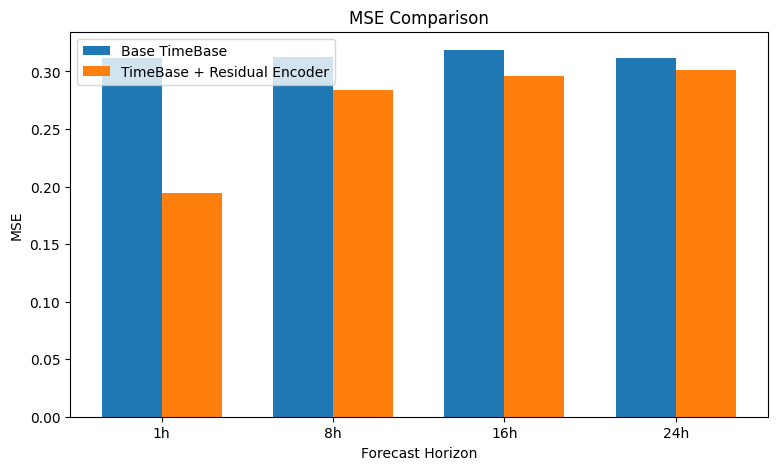

In [ ]:
mse_pivot = result_df.pivot(index="Horizon", columns="Model", values="MSE")

x = np.arange(len(HORIZONS))
w = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - w / 2,
    mse_pivot["Base TimeBase"],
    width=w,
    label="Base TimeBase"
)

plt.bar(
    x + w / 2,
    mse_pivot["TimeBase + Residual Encoder"],
    width=w,
    label="TimeBase + Residual Encoder"
)

plt.xticks(x, [f"{h}h" for h in HORIZONS])
plt.xlabel("Forecast Horizon")
plt.ylabel("MSE")
plt.title("MSE Comparison")
plt.legend()
plt.show()

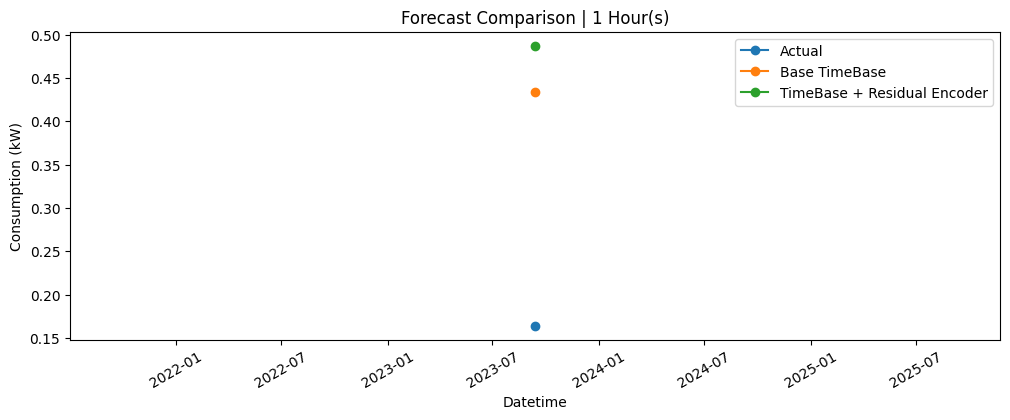

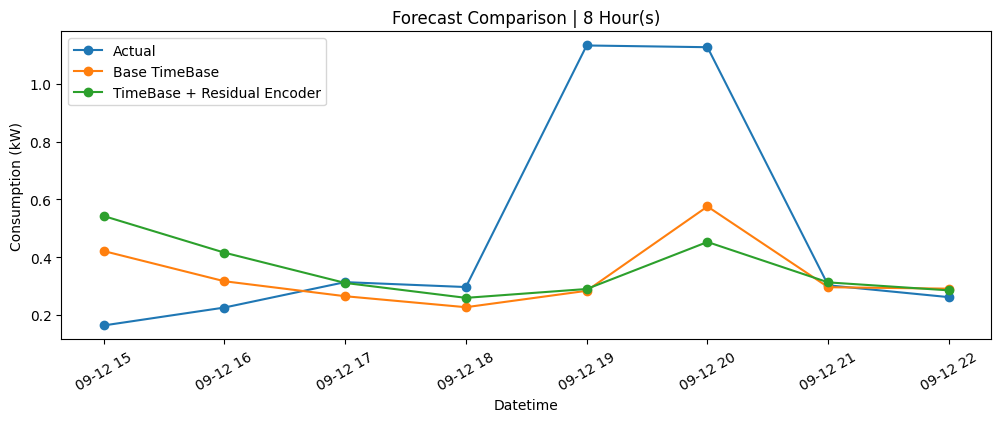

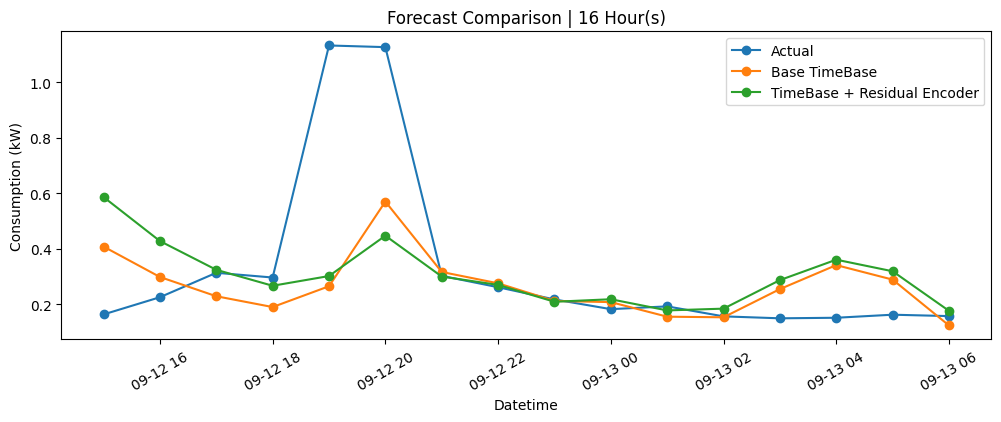

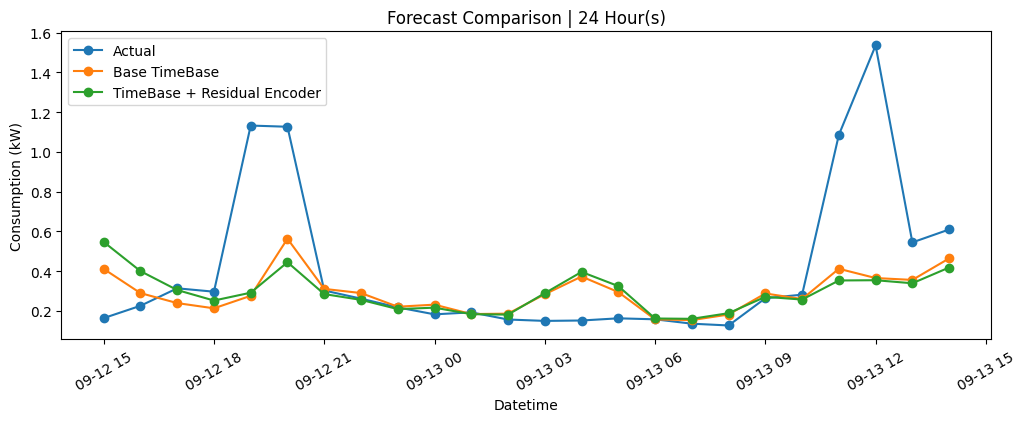

In [ ]:
for h in HORIZONS:
    base_out = None
    residual_out = None

    for x in all_results:
        if x["Horizon"] == h and x["Model"] == "Base TimeBase":
            base_out = x

        if x["Horizon"] == h and x["Model"] == "TimeBase + Residual Encoder":
            residual_out = x

    actual = base_out["Trues"][0, :, 0]
    base_pred = base_out["Preds"][0, :, 0]
    residual_pred = residual_out["Preds"][0, :, 0]

    future_time = dfh["datetime"].iloc[va_end : va_end + h]

    plt.figure(figsize=(12, 4))

    plt.plot(
        future_time,
        actual,
        marker="o",
        label="Actual"
    )

    plt.plot(
        future_time,
        base_pred,
        marker="o",
        label="Base TimeBase"
    )

    plt.plot(
        future_time,
        residual_pred,
        marker="o",
        label="TimeBase + Residual Encoder"
    )

    plt.title(f"Forecast Comparison | {h} Hour(s)")
    plt.xlabel("Datetime")
    plt.ylabel("Consumption (kW)")
    plt.legend()
    plt.xticks(rotation=30)
    plt.show()

In [ ]:
# ==================================================
# Function 1: Count model variables / parameters
# ==================================================

def count_model_variables(model, show_layers=True):
    rows = []

    total_vars = 0
    trainable_vars = 0
    non_trainable_vars = 0

    for name, param in model.named_parameters():
        n = param.numel()

        total_vars += n

        if param.requires_grad:
            trainable_vars += n
        else:
            non_trainable_vars += n

        rows.append({
            "Layer": name,
            "Shape": list(param.shape),
            "Trainable": param.requires_grad,
            "Variables": n
        })

    summary = {
        "Total Variables": total_vars,
        "Trainable Variables": trainable_vars,
        "Non-Trainable Variables": non_trainable_vars
    }

    layer_df = pd.DataFrame(rows)

    print("Total Variables:", total_vars)
    print("Trainable Variables:", trainable_vars)
    print("Non-Trainable Variables:", non_trainable_vars)

    if show_layers:
        display(layer_df)

    return summary, layer_df

In [ ]:
# ==================================================
# Function 2: Count dataset variables / features
# ==================================================

def count_dataset_variables(df, target_col=None, ignore_cols=None):
    if ignore_cols is None:
        ignore_cols = []

    cols = list(df.columns)

    usable_cols = []

    for col in cols:
        if col in ignore_cols:
            continue

        if col == target_col:
            usable_cols.append(col)
            continue

        if pd.api.types.is_numeric_dtype(df[col]):
            usable_cols.append(col)

    result = {
        "Total Columns": len(cols),
        "Usable Numeric Variables": len(usable_cols),
        "Variable Names": usable_cols,
        "Target Column": target_col
    }

    print("Total Columns:", result["Total Columns"])
    print("Usable Numeric Variables:", result["Usable Numeric Variables"])
    print("Variable Names:", result["Variable Names"])
    print("Target Column:", result["Target Column"])

    return result

In [ ]:
temp_model = TimeBaseResidualEncoder(
    seq_len=SEQ_LEN,
    pred_len=24
).to(device)

summary, layer_df = count_model_variables(temp_model, show_layers=True)

Total Variables: 11194
Trainable Variables: 11194
Non-Trainable Variables: 0


/tmp/ipykernel_1190/2706688416.py:30: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


,Layer,Shape,Trainable,Variables
0,gate,[],True,1
1,timebase.basis_extract.weight,"[6, 30]",True,180
2,timebase.basis_extract.bias,[6],True,6
3,timebase.segment_forecast.weight,"[1, 6]",True,6
4,timebase.segment_forecast.bias,[1],True,1
5,residual_encoder.pos,"[1, 48, 32]",True,1536
6,residual_encoder.value_proj.weight,"[32, 1]",True,32
7,residual_encoder.value_proj.bias,[32],True,32
8,residual_encoder.encoder.layers.0.self_attn.in...,"[96, 32]",True,3072
9,residual_encoder.encoder.layers.0.self_attn.in...,[96],True,96


In [ ]:
temp_base_model = BaseTimeBase(
    seq_len=SEQ_LEN,
    pred_len=24
).to(device)

base_summary, base_layer_df = count_model_variables(temp_base_model, show_layers=True)

Total Variables: 193
Trainable Variables: 193
Non-Trainable Variables: 0


,Layer,Shape,Trainable,Variables
0,timebase.basis_extract.weight,"[6, 30]",True,180
1,timebase.basis_extract.bias,[6],True,6
2,timebase.segment_forecast.weight,"[1, 6]",True,6
3,timebase.segment_forecast.bias,[1],True,1
